In [68]:
suppressPackageStartupMessages({
  library(conflicted)
  conflict_prefer("first",  "dplyr")
  conflict_prefer("rename", "dplyr")
  conflict_prefer("mutate", "dplyr")
  conflict_prefer("filter", "dplyr")
  conflict_prefer("select", "dplyr")

  library(dplyr)
  library(tidyr)
  library(readr)
  library(purrr)
  library(ggplot2)
  library(ggpubr)
  library(rstatix)
  library(ggforce)
  library(ggrepel)
})

[conflicted] Removing existing preference.
[conflicted] Will prefer dplyr::first over any other package.
[conflicted] Removing existing preference.
[conflicted] Will prefer dplyr::rename over any other package.
[conflicted] Removing existing preference.
[conflicted] Will prefer dplyr::mutate over any other package.
[conflicted] Removing existing preference.
[conflicted] Will prefer dplyr::filter over any other package.
[conflicted] Removing existing preference.
[conflicted] Will prefer dplyr::select over any other package.


In [69]:
# =========================================================
# Paths and thresholds
# =========================================================
setwd("/tgen_labs/barthel/projects/Jenkins_Mayo/glass_TCGA/CNVs_by_subtypes")

arm_file <- "/home/mjehangir/softwares/Arm-Level-Aneuploidy/data/genomic_arm_coordinates_hg19.txt"

In [83]:
aneuploidy_threshold <- 0.80   # fraction of arm altered to call arm-level aneuploidy
segmean_threshold    <- 0.20   # minimum |seg.mean| to call a segment altered
prefer_cna_status    <- FALSE  # set TRUE only if cna_status is already reliable
alpha_p              <- 0.05

palette_tumor <- c(
  "Astrocytoma"       = "#009E73",
  "GBM"               = "#377EB8",
  "Oligodendroglioma" = "#F0E442"
)

In [84]:
# =========================================================
# Helper functions
# =========================================================
clean_stage <- function(x) {
  case_when(
    grepl("prim", tolower(x)) ~ "Primary",
    grepl("rec",  tolower(x)) ~ "Recurrence",
    TRUE ~ x
  )
}

infer_tumor_type <- function(filename) {
  case_when(
    grepl("astro", filename, ignore.case = TRUE)        ~ "Astrocytoma",
    grepl("oligo", filename, ignore.case = TRUE)        ~ "Oligodendroglioma",
    grepl("glioblastoma", filename, ignore.case = TRUE) ~ "GBM",
    TRUE                                                 ~ "Other"
  )
}

infer_stage <- function(filename) {
  ifelse(grepl("primary", filename, ignore.case = TRUE), "Primary", "Recurrence")
}

format_pvalue_label <- function(p) {
  ifelse(
    is.na(p),
    NA_character_,
    ifelse(p < 0.001, formatC(p, format = "e", digits = 1), sprintf("%.4f", p))
  )
}

make_pairwise_labels <- function(data, value_col, group_col = "tumor_type", step_fraction = 0.12) {
  max_y <- max(data[[value_col]], na.rm = TRUE)
  groups <- levels(data[[group_col]])
  comparisons <- combn(groups, 2, simplify = FALSE)
  step <- max(0.02, max_y * step_fraction)
  label_y <- max_y + seq_along(comparisons) * step

  list(comparisons = comparisons, step = step, label_y = label_y)
}

make_group_n_labels <- function(data, x_col, y_col, step) {
  data %>%
    group_by(.data[[x_col]]) %>%
    summarise(
      y = max(.data[[y_col]], na.rm = TRUE) + step * 0.6,
      n = n(),
      .groups = "drop"
    )
}

In [85]:
# =========================================================
# Load chromosome arm coordinates
# =========================================================
arm_lengths <- read_tsv(arm_file, col_types = cols(), comment = "#") %>%
  rename(arm_start = start, arm_end = end) %>%
  mutate(
    chrom = ifelse(grepl("^chr", chrom), chrom, paste0("chr", chrom)),
    arm_length = arm_end - arm_start
  ) %>%
  select(chrom, side, arm, arm_start, arm_end, arm_length)

In [86]:
# =========================================================
# Load CNV segment files
# =========================================================
segment_files <- list.files(pattern = "_(primary|recurrence)\\.seg$")

cnv_all <- map_dfr(segment_files, function(file) {
  read.table(file, header = TRUE, sep = "\t") %>%
    mutate(
      tumor_type = infer_tumor_type(file),
      stage = infer_stage(file),
      sample = ID,
      row_id = paste0(file, "_", seq_len(n())),
      chrom = ifelse(grepl("^chr", chrom), chrom, paste0("chr", chrom)),
      segment_length = loc.end - loc.start
    )
})

In [87]:
# =========================================================
# Join segments to chromosome arms and compute overlap
# =========================================================
cnv_with_arms <- cnv_all %>%
  left_join(arm_lengths, by = "chrom") %>%
  filter(loc.start < arm_end, loc.end > arm_start) %>%
  mutate(
    overlap_start = pmax(loc.start, arm_start),
    overlap_end   = pmin(loc.end, arm_end),
    overlap_len   = pmax(0, overlap_end - overlap_start),
    arm_fraction  = overlap_len / arm_length,
    cna_status    = case_when(
      seg.mean > 0 ~ 1,
      seg.mean < 0 ~ -1,
      TRUE         ~ 0
    ),
    stage = clean_stage(stage)
  ) %>%
  filter(stage %in% c("Primary", "Recurrence"))

Warning message in left_join(., arm_lengths, by = "chrom"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


In [88]:
# =========================================================
# Basic QC summaries
# =========================================================
cat("Project prefix distribution:\n")
print(table(substr(cnv_with_arms$ID, 1, 4)))

cat("\nStage distribution:\n")
print(table(cnv_with_arms$stage))

cat("\nSummary of seg.mean:\n")
print(summary(cnv_with_arms$seg.mean))

summary_table <- cnv_with_arms %>%
  filter(cna_status %in% c(-1, 1)) %>%
  group_by(tumor_type, stage) %>%
  summarise(unique_samples = n_distinct(sample), .groups = "drop") %>%
  pivot_wider(names_from = stage, values_from = unique_samples, values_fill = 0) %>%
  mutate(Total = Primary + Recurrence)

summary_table <- bind_rows(
  summary_table,
  tibble(
    tumor_type = "Total",
    Primary = sum(summary_table$Primary),
    Recurrence = sum(summary_table$Recurrence),
    Total = sum(summary_table$Total)
  )
)

print(summary_table)

Project prefix distribution:

  GLSS   P-00   Pati   TCGA 
182855   9236    177  60397 

Stage distribution:

   Primary Recurrence 
    112116     140549 

Summary of seg.mean:
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
-31.48688  -0.60651  -0.09548  -0.55884   0.06100   9.53808 
# A tibble: 4 × 4
  tumor_type        Primary Recurrence Total
  <chr>               <int>      <int> <int>
1 Astrocytoma           130         78   208
2 GBM                   174        205   379
3 Oligodendroglioma     126         47   173
4 Total                 430        330   760


In [89]:
# =========================================================
# Derive per-sample arm-level and segmental scores
# =========================================================
score_samples <- function(df, by_stage = FALSE) {
  df2 <- df %>%
    mutate(
      arm_length  = as.numeric(arm_length),
      overlap_len = as.numeric(overlap_len),
      seg.mean    = as.numeric(seg.mean),
      cna_status  = suppressWarnings(as.numeric(cna_status)),
      is_altered  = if (prefer_cna_status && any(!is.na(cna_status))) {
        cna_status != 0
      } else {
        abs(seg.mean) >= segmean_threshold
      }
    )

  group_vars_arm <- c("ID", "tumor_type", "arm")
  group_vars_sample <- c("ID", "tumor_type")

  if (by_stage) {
    group_vars_arm <- c("ID", "tumor_type", "stage", "arm")
    group_vars_sample <- c("ID", "tumor_type", "stage")
  }

  arm_summary <- df2 %>%
    group_by(across(all_of(group_vars_arm))) %>%
    summarise(
      arm_length = max(arm_length, na.rm = TRUE),
      altered_bp = sum(overlap_len[is_altered], na.rm = TRUE),
      .groups = "drop"
    ) %>%
    mutate(
      altered_bp = pmin(altered_bp, arm_length),
      frac_altered = ifelse(arm_length > 0, altered_bp / arm_length, NA_real_),
      is_aneuploid = frac_altered >= aneuploidy_threshold
    )

  sample_scores <- arm_summary %>%
    group_by(across(all_of(group_vars_sample))) %>%
    summarise(
      n_aneuploid_arms = sum(is_aneuploid, na.rm = TRUE),
      segmental_bp = sum(altered_bp[!is_aneuploid], na.rm = TRUE),
      total_arm_bp = sum(arm_length, na.rm = TRUE),
      segmental_cnv_burden = segmental_bp / total_arm_bp,
      .groups = "drop"
    )

  list(arm_summary = arm_summary, sample_scores = sample_scores)
}

scores_overall <- score_samples(cnv_with_arms, by_stage = FALSE)
arm_summary_overall <- scores_overall$arm_summary
sample_scores_overall <- scores_overall$sample_scores

scores_stage <- score_samples(cnv_with_arms, by_stage = TRUE)
arm_summary_stage <- scores_stage$arm_summary
sample_scores_stage <- scores_stage$sample_scores

# A tibble: 3 × 8
  .y.              group1      group2        p    p.adj p.format p.signif method
  <chr>            <chr>       <chr>     <dbl>    <dbl> <chr>    <chr>    <chr> 
1 n_aneuploid_arms Astrocytoma GBM    2.99e-22 9   e-22 < 2e-16  ****     Wilco…
2 n_aneuploid_arms Astrocytoma Oligo… 8.48e- 6 8.5 e- 6 8.5e-06  ****     Wilco…
3 n_aneuploid_arms GBM         Oligo… 2.95e-15 4.40e-15 3.0e-15  ****     Wilco…


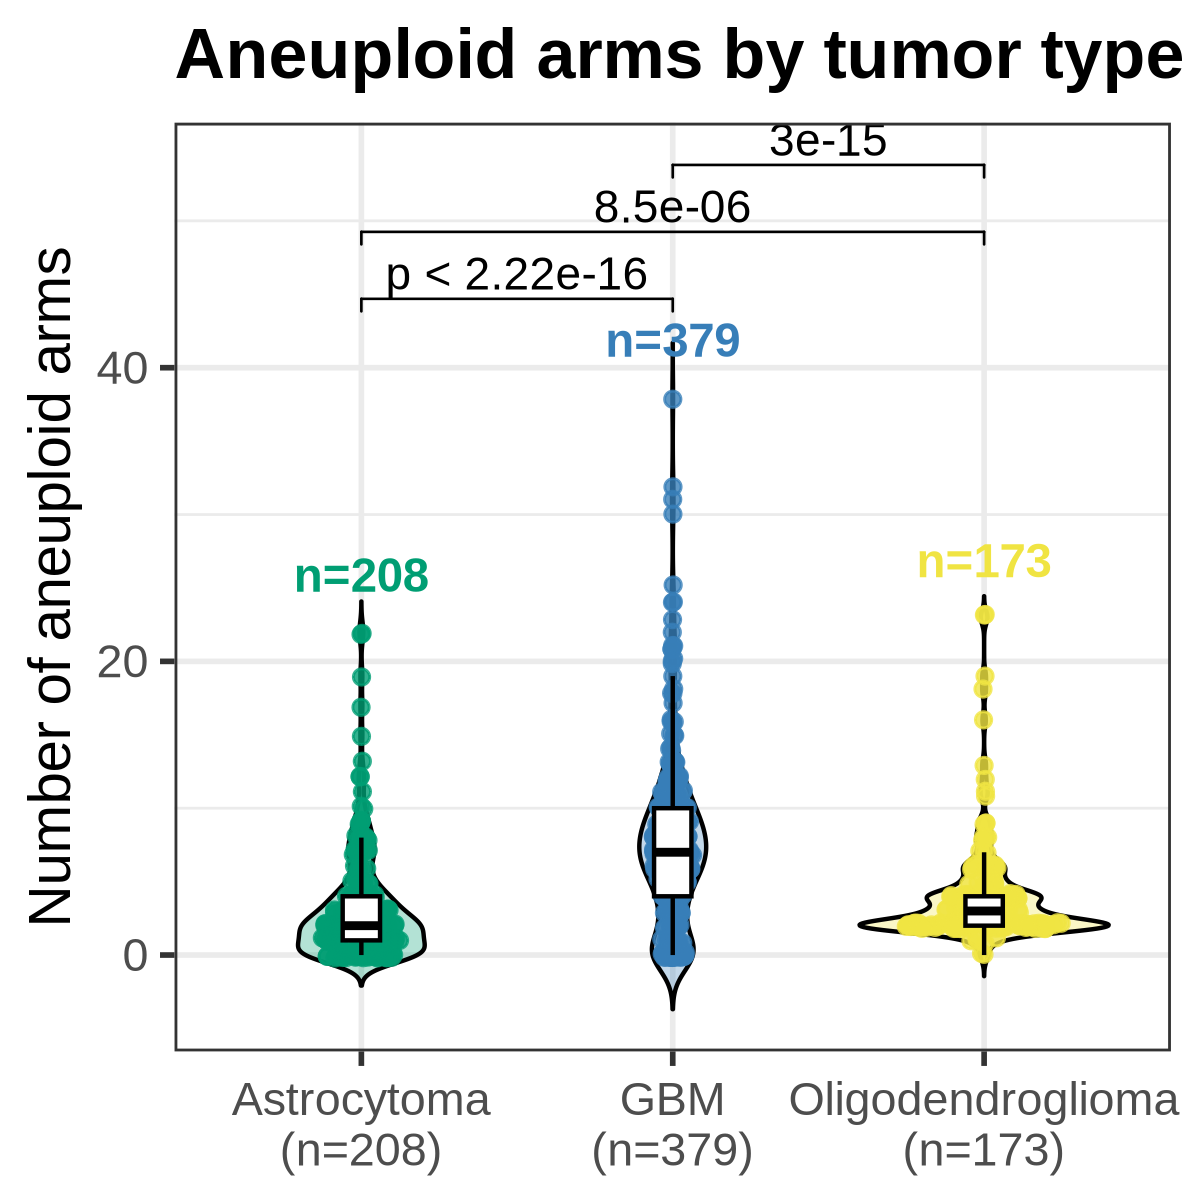

In [90]:
# =========================================================
#####aneuploid arms by tumor type
# =========================================================
dat_aneu <- sample_scores_overall %>%
  filter(!is.na(tumor_type), !is.na(n_aneuploid_arms)) %>%
  mutate(tumor_type = factor(tumor_type, levels = names(palette_tumor)))

pair_info_aneu <- make_pairwise_labels(dat_aneu, value_col = "n_aneuploid_arms")
counts_aneu <- dat_aneu %>% count(tumor_type, name = "n")
axis_labels_aneu <- function(x) paste0(x, "\n(n=", counts_aneu$n[match(x, counts_aneu$tumor_type)], ")")
n_pos_aneu <- make_group_n_labels(dat_aneu, x_col = "tumor_type", y_col = "n_aneuploid_arms", step = pair_info_aneu$step)

p_aneu_tumor <- ggplot(dat_aneu, aes(x = tumor_type, y = n_aneuploid_arms, fill = tumor_type)) +
  geom_violin(alpha = 0.3, trim = FALSE, width = 0.8, color = "black") +
  ggforce::geom_sina(aes(color = tumor_type), alpha = 0.8, size = 1.5, maxwidth = 0.5) +
  geom_boxplot(fill = "white", width = 0.12, outlier.shape = NA, color = "black") +
  stat_compare_means(
    comparisons = pair_info_aneu$comparisons,
    method = "wilcox.test",
    p.adjust.method = "BH",
    aes(label = ifelse(after_stat(p.adj) < 0.001,
                       formatC(after_stat(p.adj), format = "e", digits = 1),
                       sprintf("%.4f", after_stat(p.adj)))),
    label.y = pair_info_aneu$label_y,
    tip.length = 0.02
  ) +
  geom_text(
    data = n_pos_aneu,
    aes(x = tumor_type, y = y, label = paste0("n=", n), color = tumor_type),
    inherit.aes = FALSE,
    vjust = 0,
    fontface = "bold",
    size = 4
  ) +
  scale_fill_manual(values = palette_tumor) +
  scale_color_manual(values = palette_tumor) +
  scale_x_discrete(labels = axis_labels_aneu) +
  labs(
    x = NULL,
    y = "Number of aneuploid arms",
    title = "Aneuploid arms by tumor type"
  ) +
  theme_bw(base_size = 14) +
  theme(
    legend.position = "none",
    plot.title = element_text(face = "bold"),
    axis.text.x = element_text(vjust = 0.5)
  ) +
  expand_limits(y = max(n_pos_aneu$y) + pair_info_aneu$step * 0.4)

print(p_aneu_tumor)

aneu_stats <- compare_means(
  n_aneuploid_arms ~ tumor_type,
  data = dat_aneu,
  method = "wilcox.test",
  p.adjust.method = "BH"
)
print(aneu_stats)

# A tibble: 3 × 8
  .y.                  group1   group2        p   p.adj p.format p.signif method
  <chr>                <chr>    <chr>     <dbl>   <dbl> <chr>    <chr>    <chr> 
1 segmental_cnv_burden Astrocy… GBM    1.77e- 4 1.8e- 4 0.00018  ***      Wilco…
2 segmental_cnv_burden Astrocy… Oligo… 1.15e-23 3.5e-23 < 2e-16  ****     Wilco…
3 segmental_cnv_burden GBM      Oligo… 2.52e-17 3.8e-17 < 2e-16  ****     Wilco…


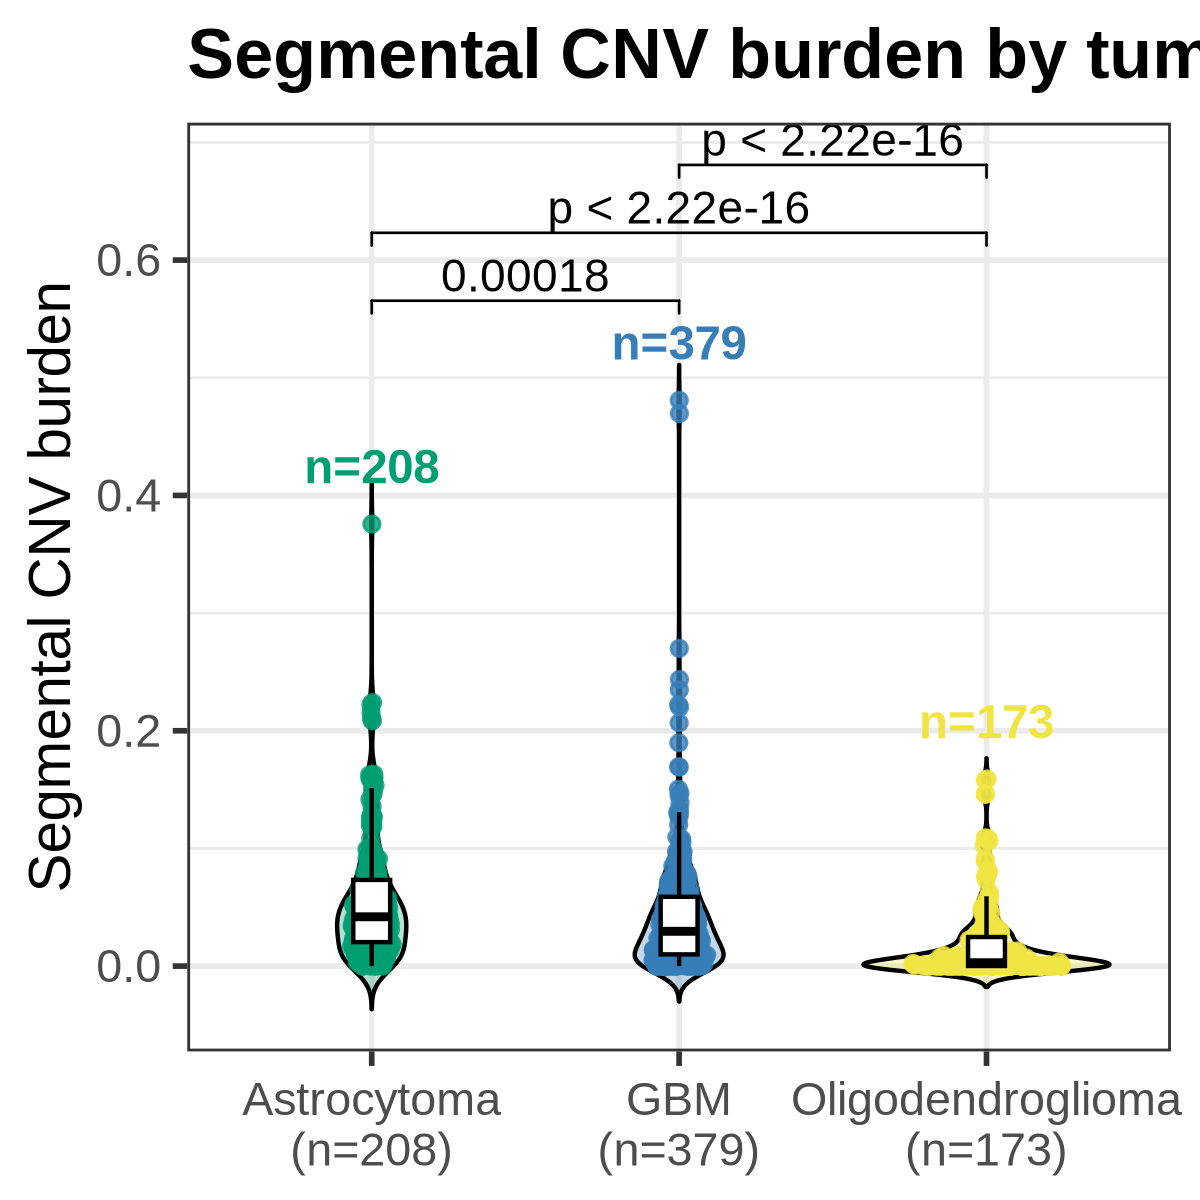

In [91]:
# =========================================================
# segmental CNV burden by tumor type
# =========================================================
dat_burden <- sample_scores_overall %>%
  filter(!is.na(tumor_type), !is.na(segmental_cnv_burden)) %>%
  mutate(tumor_type = factor(tumor_type, levels = names(palette_tumor)))

pair_info_burden <- make_pairwise_labels(dat_burden, value_col = "segmental_cnv_burden")
n_pos_burden <- make_group_n_labels(dat_burden, x_col = "tumor_type", y_col = "segmental_cnv_burden", step = pair_info_burden$step)

p_burden_tumor <- ggplot(dat_burden, aes(x = tumor_type, y = segmental_cnv_burden, fill = tumor_type)) +
  geom_violin(alpha = 0.3, trim = FALSE, width = 0.8, color = "black") +
  ggforce::geom_sina(aes(color = tumor_type), alpha = 0.8, size = 1.5, maxwidth = 0.5) +
  geom_boxplot(fill = "white", width = 0.12, outlier.shape = NA, color = "black") +
  stat_compare_means(
    comparisons = pair_info_burden$comparisons,
    method = "wilcox.test",
    p.adjust.method = "BH",
    aes(label = ifelse(after_stat(p.adj) < 0.001,
                       formatC(after_stat(p.adj), format = "e", digits = 1),
                       sprintf("%.4f", after_stat(p.adj)))),
    label.y = pair_info_burden$label_y,
    tip.length = 0.02
  ) +
  geom_text(
    data = n_pos_burden,
    aes(x = tumor_type, y = y, label = paste0("n=", n), color = tumor_type),
    inherit.aes = FALSE,
    vjust = 0,
    fontface = "bold",
    size = 4
  ) +
  scale_fill_manual(values = palette_tumor) +
  scale_color_manual(values = palette_tumor) +
  scale_x_discrete(labels = function(x) paste0(x, "\n(n=", table(dat_burden$tumor_type)[x], ")")) +
  labs(
    x = NULL,
    y = "Segmental CNV burden",
    title = "Segmental CNV burden by tumor type"
  ) +
  theme_bw(base_size = 14) +
  theme(
    legend.position = "none",
    plot.title = element_text(face = "bold"),
    axis.text.x = element_text(vjust = 0.5)
  ) +
  expand_limits(y = max(n_pos_burden$y) + pair_info_burden$step * 0.4)

print(p_burden_tumor)

burden_stats <- compare_means(
  segmental_cnv_burden ~ tumor_type,
  data = dat_burden,
  method = "wilcox.test",
  p.adjust.method = "BH"
)
print(burden_stats)

In [92]:
# =========================================================
# Optional: arm-level recurrence vs primary comparison for volcano input
# =========================================================
eps <- 1e-6

arm_by_sample <- cnv_with_arms %>%
  mutate(
    arm_length  = as.numeric(arm_length),
    overlap_len = as.numeric(overlap_len),
    seg.mean    = as.numeric(seg.mean),
    cna_status  = suppressWarnings(as.numeric(cna_status)),
    stage       = clean_stage(stage),
    is_altered  = if (prefer_cna_status && any(!is.na(cna_status))) {
      cna_status != 0
    } else {
      abs(seg.mean) >= segmean_threshold
    }
  ) %>%
  filter(stage %in% c("Primary", "Recurrence")) %>%
  group_by(ID, tumor_type, stage, arm) %>%
  summarise(
    arm_length = max(arm_length, na.rm = TRUE),
    altered_bp = sum(overlap_len[is_altered], na.rm = TRUE),
    gain_bp    = sum(overlap_len[is_altered & seg.mean >  0], na.rm = TRUE),
    loss_bp    = sum(overlap_len[is_altered & seg.mean <  0], na.rm = TRUE),
    amp_len    = sum(abs(seg.mean[is_altered]) * overlap_len[is_altered], na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    altered_bp   = pmin(altered_bp, arm_length),
    frac_altered = ifelse(arm_length > 0, altered_bp / arm_length, NA_real_),
    frac_gain    = ifelse(arm_length > 0, pmin(gain_bp, arm_length) / arm_length, NA_real_),
    frac_loss    = ifelse(arm_length > 0, pmin(loss_bp, arm_length) / arm_length, NA_real_),
    cna_volume   = ifelse(arm_length > 0, amp_len / arm_length, NA_real_),
    is_aneuploid = frac_altered >= aneuploidy_threshold
  )

wilcox_delta <- function(x_primary, x_recurrence, delta_fun) {
  med_primary <- suppressWarnings(median(x_primary, na.rm = TRUE))
  med_recurrence <- suppressWarnings(median(x_recurrence, na.rm = TRUE))
  pval <- tryCatch(
    if (length(na.omit(x_primary)) > 0 && length(na.omit(x_recurrence)) > 0) {
      wilcox.test(x_recurrence, x_primary, exact = FALSE)$p.value
    } else {
      NA_real_
    },
    error = function(e) NA_real_
  )
  tibble(delta = delta_fun(med_primary, med_recurrence), pvalue = pval)
}

volcano_log2_or_aneuploid <- arm_by_sample %>%
  group_by(tumor_type, arm) %>%
  group_modify(~{
    d <- .x
    a <- sum(d$is_aneuploid & d$stage == "Recurrence", na.rm = TRUE)
    b <- sum(!d$is_aneuploid & d$stage == "Recurrence", na.rm = TRUE)
    c <- sum(d$is_aneuploid & d$stage == "Primary",    na.rm = TRUE)
    e <- sum(!d$is_aneuploid & d$stage == "Primary",    na.rm = TRUE)

    contingency <- matrix(
      c(a, b, c, e),
      nrow = 2,
      byrow = TRUE,
      dimnames = list(
        Stage = c("Recurrence", "Primary"),
        Aneuploid = c("Yes", "No")
      )
    )

    pval <- tryCatch(fisher.test(contingency)$p.value, error = function(x) NA_real_)
    log2_or <- log2(((a + 0.5) / (b + 0.5)) / ((c + 0.5) / (e + 0.5)))

    tibble(delta_genome_instability = log2_or, pvalue = pval)
  }) %>%
  ungroup()

print(head(volcano_log2_or_aneuploid))



# A tibble: 6 × 4
  tumor_type  arm   delta_genome_instability  pvalue
  <chr>       <chr>                    <dbl>   <dbl>
1 Astrocytoma 10p                     0.651  0.179  
2 Astrocytoma 10q                     1.86   0.00234
3 Astrocytoma 11p                    -0.499  0.365  
4 Astrocytoma 11q                     0.0411 1      
5 Astrocytoma 12p                    -0.619  0.452  
6 Astrocytoma 12q                    -0.945  0.235  


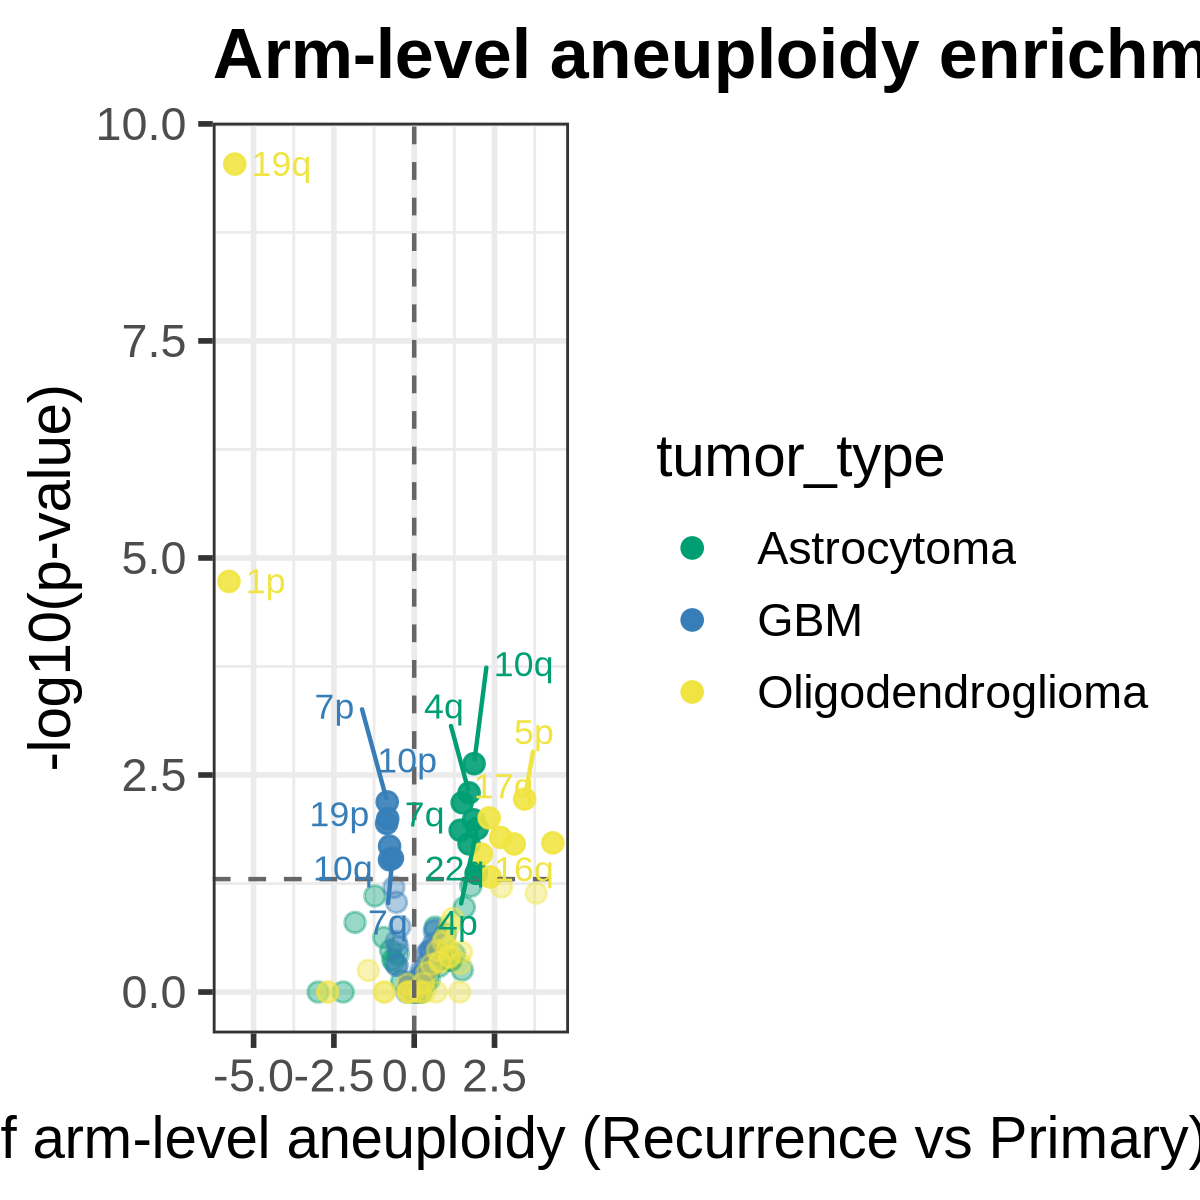

In [93]:
# Volcano plot (all tumor types together)
volc <- volcano_log2_or_aneuploid %>%
  filter(!is.na(pvalue), !is.na(delta_genome_instability)) %>%
  mutate(
    tumor_type = factor(tumor_type, levels = names(palette_tumor)),
    pvalue = pmax(pvalue, .Machine$double.xmin),
    neglog10p = -log10(pvalue),
    significant = pvalue < alpha_p
  )

top_hits <- volc %>%
  group_by(tumor_type) %>%
  slice_max(order_by = neglog10p, n = 5, with_ties = FALSE) %>%
  ungroup()

p_volcano <- ggplot(volc, aes(x = delta_genome_instability, y = neglog10p, color = tumor_type)) +
  geom_point(aes(alpha = significant), size = 2) +
  geom_hline(yintercept = -log10(alpha_p), linetype = 2, color = "grey40") +
  geom_vline(xintercept = 0, linetype = 2, color = "grey40") +
  ggrepel::geom_text_repel(
    data = top_hits,
    aes(label = arm),
    size = 3,
    show.legend = FALSE,
    max.overlaps = Inf
  ) +
  scale_color_manual(values = palette_tumor) +
  scale_alpha_manual(values = c(`TRUE` = 0.9, `FALSE` = 0.4), guide = "none") +
  labs(
    x = "log2 odds ratio of arm-level aneuploidy (Recurrence vs Primary)",
    y = "-log10(p-value)",
    title = "Arm-level aneuploidy enrichment by stage"
  ) +
  theme_bw(base_size = 14) +
  theme(
    legend.position = "right",
    plot.title = element_text(face = "bold")
  )

print(p_volcano)

In [ ]:
# Example save commands
# ggsave("aneuploid_arms_by_tumor_type.pdf", p_aneu_tumor, width = 5, height = 5)
# ggsave("segmental_cnv_burden_by_tumor_type.pdf", p_burden_tumor, width = 5, height = 5)
# ggsave("aneuploid_arms_by_stage.pdf", p_stage_aneu, width = 8, height = 4)
# ggsave("segmental_cnv_burden_by_stage.pdf", p_stage_burden, width = 8, height = 4)